# TravelTide Mastery Project

## Kundensegmentierung und Perk-Zuweisung

### Ziel des Notebooks

In diesem Notebook werden die im Rahmen der Datenaufbereitung entwickelten
Kundenmerkmale genutzt, um Kunden mit ähnlichem Reise-, Buchungs- und
Nutzungsverhalten zu identifizieren.

Hierfür werden zunächst geeignete Merkmale für die Segmentierung ausgewählt
und vorbereitet. Anschließend werden verschiedene Verfahren zur
Kundensegmentierung untersucht:

- K-Means-Clustering
- DBSCAN
- Dimensionsreduktion mit PCA

Die Ergebnisse der Verfahren werden anhand geeigneter Kennzahlen sowie ihrer
inhaltlichen Interpretierbarkeit verglichen. Auf Grundlage der finalen
Kundensegmente werden die charakteristischen Verhaltensweisen der einzelnen
Gruppen beschrieben und verständliche Segmentbezeichnungen entwickelt.

Abschließend wird jedem Kunden ein voraussichtlich passender Benefit aus dem
geplanten TravelTide-Rewards-Programm zugeordnet:

- kostenlose Hotelmahlzeit
- kostenloses Aufgabegepäck
- keine Stornierungsgebühren
- exklusive Rabatte
- kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung

Das Ergebnis ist eine finale Kundentabelle, die neben den aufbereiteten
Kundenmerkmalen auch die Segmentzugehörigkeit und den empfohlenen Benefit
enthält.

## 1. Datenimport und erste Datenprüfung

Zunächst wird die in Notebook 01 erstellte finale Kundentabelle eingelesen.
Sie enthält pro Kunde genau eine Zeile sowie die aufbereiteten demografischen,
verhaltensbezogenen und monetären Merkmale.

Vor der Segmentierung werden die Dimensionen der Tabelle, die Eindeutigkeit
der Nutzer, die Datentypen sowie die vorhandenen Spalten überprüft. Dadurch
wird sichergestellt, dass die Daten vollständig und in der erwarteten
Struktur vorliegen.

In [1]:
# Bibliotheken importieren

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

In [2]:
# Finale Kundentabelle aus der Datenaufbereitung einlesen

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

print(f"Zeilen: {customer_features.shape[0]}")
print(f"Spalten: {customer_features.shape[1]}")

display(customer_features.head())

Zeilen: 5752
Spalten: 79


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,"3,802.000","1,901.000","3,670.500","1,835.250","3,670.500","1,835.250",20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,"3,670.500"
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,"1,094.090"
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,"2,199.000","1,099.500","2,199.000","1,099.500","2,199.000","1,099.500",8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,"2,388.910"
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,42,526,17.280,8,1.962,2.217,126,15.750,0.125,5,5,5,5,0,2,1,0.150,0.100,1,0,0.625,0.000,1.000,0.500,0.000,5.000,"1,242.660","1,237.693","1,237.693",247.539,5.000,1.000,2.000,0.400,247.539,1.000,0.000,247.539,5.000,"2,429.000",485.800,"2,429.000",485.800,"2,429.000",485.800,19.000,3.800,5.000,1.000,136.000,132.000,5.000,5.000,1.000,0.200,0.000,Luxury,Charlotte,0.200,0.400,0.400,0.000,True,True,True,0.400,0.000,"3,666.693"
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,44,519,17.050,8,12.649,2.392,240,30.000,0.000,1,1,1,1,1,1,1,NaN,NaN,0,0,0.125,0.125,1.000,0.000,0.000,1.

In [3]:
# Struktur und Datentypen prüfen

customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   user_id                                       5752 non-null   int64  
 1   birthdate                                     5752 non-null   str    
 2   gender                                        5752 non-null   str    
 3   married                                       5752 non-null   bool   
 4   has_children                                  5752 non-null   bool   
 5   home_country                                  5752 non-null   str    
 6   home_city                                     5752 non-null   str    
 7   home_airport                                  5752 non-null   str    
 8   home_airport_lat                              5752 non-null   float64
 9   home_airport_lon                              5752 non-null   float64
 10 

In [4]:
# Anzahl eindeutiger Kunden prüfen

print(
    "Eindeutige Nutzer:",
    customer_features["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customer_features["user_id"].duplicated().sum()
)

Eindeutige Nutzer: 5752
Doppelte Nutzer: 0


In [5]:
# Alle vorhandenen Spalten (= Merkmale) übersichtlich anzeigen.

columns_overview = pd.DataFrame({
    "column": customer_features.columns,
    "dtype": customer_features.dtypes.astype(str).values,
    "missing_values": customer_features.isna().sum().values,
    "unique_values": customer_features.nunique(dropna=False).values
})

display(columns_overview)

,column,dtype,missing_values,unique_values
0,user_id,int64,0,5752
1,birthdate,str,0,4625
2,gender,str,0,3
3,married,bool,0,2
4,has_children,bool,0,2
5,home_country,str,0,2
6,home_city,str,0,105
7,home_airport,str,0,159
8,home_airport_lat,float64,0,158
9,home_airport_lon,float64,0,158


In [6]:
# Numerische und nicht numerische Spalten unterscheiden

numeric_columns = customer_features.select_dtypes(
    include="number"
).columns.tolist()

non_numeric_columns = customer_features.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerische Spalten:")
display(numeric_columns)

print("\nNicht numerische Spalten:")
display(non_numeric_columns)

Numerische Spalten:


['user_id',
 'home_airport_lat',
 'home_airport_lon',
 'age',
 'customer_tenure_days',
 'customer_tenure_months',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'tota


Nicht numerische Spalten:


['birthdate',
 'gender',
 'married',
 'has_children',
 'home_country',
 'home_city',
 'home_airport',
 'sign_up_date',
 'preferred_hotel_segment',
 'preferred_hotel_city',
 'has_flight_booking',
 'has_hotel_booking',
 'has_travel_booking']

## 2. Merkmalsauswahl

Für die Kundensegmentierung werden Merkmale ausgewählt, die unterschiedliche
Aspekte des bisherigen Kundenverhaltens abbilden. Dazu gehören die Nutzung
der Plattform, das Buchungs- und Stornierungsverhalten, die Reaktion auf
Rabattangebote sowie das Flug- und Hotelverhalten.

Identifikationsmerkmale, demografische Angaben und geografische Koordinaten
werden nicht für die Berechnung der Cluster verwendet. Sie können später zur
inhaltlichen Beschreibung der Kundensegmente herangezogen werden.

Bei mehreren stark verwandten Merkmalen wird zunächst nur eine repräsentative
Variable ausgewählt. Dadurch soll verhindert werden, dass einzelne
Verhaltensaspekte im Clustering mehrfach gewichtet werden.

In [7]:
# Merkmale nach Funktion einteilen.

identifier_columns = [
    "user_id"
]

descriptive_candidates = [
    "age",
    "gender",
    "married",
    "has_children",
    "home_country",
    "customer_tenure_days",
    "customer_tenure_months"
]

descriptive_columns = [
    column
    for column in descriptive_candidates
    if column in customer_features.columns
]

behavior_columns = [
    column
    for column in numeric_columns
    if column not in identifier_columns + descriptive_columns
]

print("Identifikationsmerkmale:")
print(identifier_columns)

print("\nBeschreibende Merkmale:")
print(descriptive_columns)

print("\nMögliche Verhaltensmerkmale:")
display(behavior_columns)

Identifikationsmerkmale:
['user_id']

Beschreibende Merkmale:
['age', 'gender', 'married', 'has_children', 'home_country', 'customer_tenure_days', 'customer_tenure_months']

Mögliche Verhaltensmerkmale:


['home_airport_lat',
 'home_airport_lon',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'total_checked_bags',
 'mean_checked_bags',
 'mean_fare_per_seat_after_discou

In [8]:
# Vorauswahl potenzieller Clustering-Merkmale

clustering_feature_candidates = [
    # Nutzung der Plattform
    "mean_session_duration_minutes",
    "mean_page_clicks",
    "low_click_session_rate",

    # Allgemeines Buchungs- und Stornierungsverhalten
    "booking_session_rate",
    "cancellation_session_rate",
    "package_booking_rate",

    # Reaktion auf Rabattangebote
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",

    # Flugverhalten
    "flight_booking_count",
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "hotel_booking_count",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share",

    # Bisheriger monetärer Kundenwert
    "historical_customer_value_usd"
]

# Prüfen, ob alle ausgewählten Spalten vorhanden sind

missing_candidate_columns = [
    column
    for column in clustering_feature_candidates
    if column not in customer_features.columns
]

print("Anzahl vorausgewählter Merkmale:",
      len(clustering_feature_candidates))

print("Nicht gefundene Merkmale:",
      missing_candidate_columns)

Anzahl vorausgewählter Merkmale: 18
Nicht gefundene Merkmale: []


In [9]:
# Arbeitstabelle für die weitere Merkmalsprüfung erstellen

clustering_candidates = (
    customer_features[
        ["user_id"] + clustering_feature_candidates
    ]
    .copy()
)

display(clustering_candidates.head())

,user_id,mean_session_duration_minutes,mean_page_clicks,low_click_session_rate,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share,historical_customer_value_usd
0,23557,1.277,10.250,0.000,0.250,0.000,0.000,NaN,0.500,0.000,NaN,0.000,NaN,NaN,2.000,10.000,177.000,0.500,"3,670.500"
1,94883,1.129,9.125,0.000,0.250,0.000,1.000,NaN,0.000,2.000,1.500,0.333,1.000,288.030,2.000,1.000,90.000,0.000,"1,094.090"
2,101486,2.038,16.375,0.000,0.250,0.000,0.500,0.000,NaN,1.000,1.000,0.000,1.000,189.910,2.000,4.000,198.500,0.000,"2,388.910"
3,101961,1.962,15.750,0.125,0.625,0.000,1.000,0.500,0.000,5.000,1.000,0.400,1.000,247.539,5.000,3.800,132.000,0.200,"3,666.693"
4,106907,12.649,30.000,0.000,0.125,0.125,1.000,0.000,0.000,1.000,6.000,0.833,1.000,"2,317.010",1.000,11.000,129.000,0.000,0.000


In [10]:
# Statistische Übersicht der vorausgewählten Merkmale

candidate_overview = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .describe()
    .T
)

candidate_overview["missing_values"] = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .isna()
    .sum()
)

candidate_overview["missing_share"] = (
    candidate_overview["missing_values"]
    / len(clustering_candidates)
)

candidate_overview["unique_values"] = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .nunique()
)

display(candidate_overview)

,count,mean,std,min,25%,50%,75%,max,missing_values,missing_share,unique_values
mean_session_duration_minutes,"5,752.000",3.116,4.002,0.525,1.567,1.948,2.465,35.627,0,0.000,2514
mean_page_clicks,"5,752.000",17.685,8.733,4.125,12.625,15.625,19.688,109.125,0,0.000,681
low_click_session_rate,"5,752.000",0.009,0.032,0.000,0.000,0.000,0.000,0.250,0,0.000,6
booking_session_rate,"5,752.000",0.336,0.184,0.000,0.222,0.375,0.500,1.000,0,0.000,28
cancellation_session_rate,"5,752.000",0.012,0.038,0.000,0.000,0.000,0.000,0.250,0,0.000,8
package_booking_rate,"5,360.000",0.722,0.319,0.000,0.500,0.750,1.000,1.000,392,0.068,17
flight_discount_conversion_rate,"4,617.000",0.231,0.348,0.000,0.000,0.000,0.500,1.000,1135,0.197,10
hotel_discount_conversion_rate,"4,032.000",0.286,0.388,0.000,0.000,0.000,0.500,1.000,1720,0.299,11
flight_booking_count,"5,752.000",2.357,1.497,0.000,1.000,2.000,3.000,8.000,0,0.000,9
mean_seats,"5,057.000",1.212,0.434,1.000,1.000,1.000,1.333,6.000,695,0.121,31


In [11]:
# Fehlende Werte der Kandidaten übersichtlich darstellen

missing_overview = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={
        "sum": "missing_values",
        "mean": "missing_share"
    })
    .sort_values(
        "missing_values",
        ascending=False
    )
)

display(missing_overview)

,missing_values,missing_share
hotel_discount_conversion_rate,"1,720.000",0.299
flight_discount_conversion_rate,"1,135.000",0.197
weighted_fare_per_seat_after_discount_usd,695.000,0.121
return_flight_rate,695.000,0.121
mean_seats,695.000,0.121
median_hotel_price_per_room_usd,512.000,0.089
mean_hotel_nights,512.000,0.089
package_booking_rate,392.000,0.068
mean_page_clicks,0.000,0.000
mean_session_duration_minutes,0.000,0.000


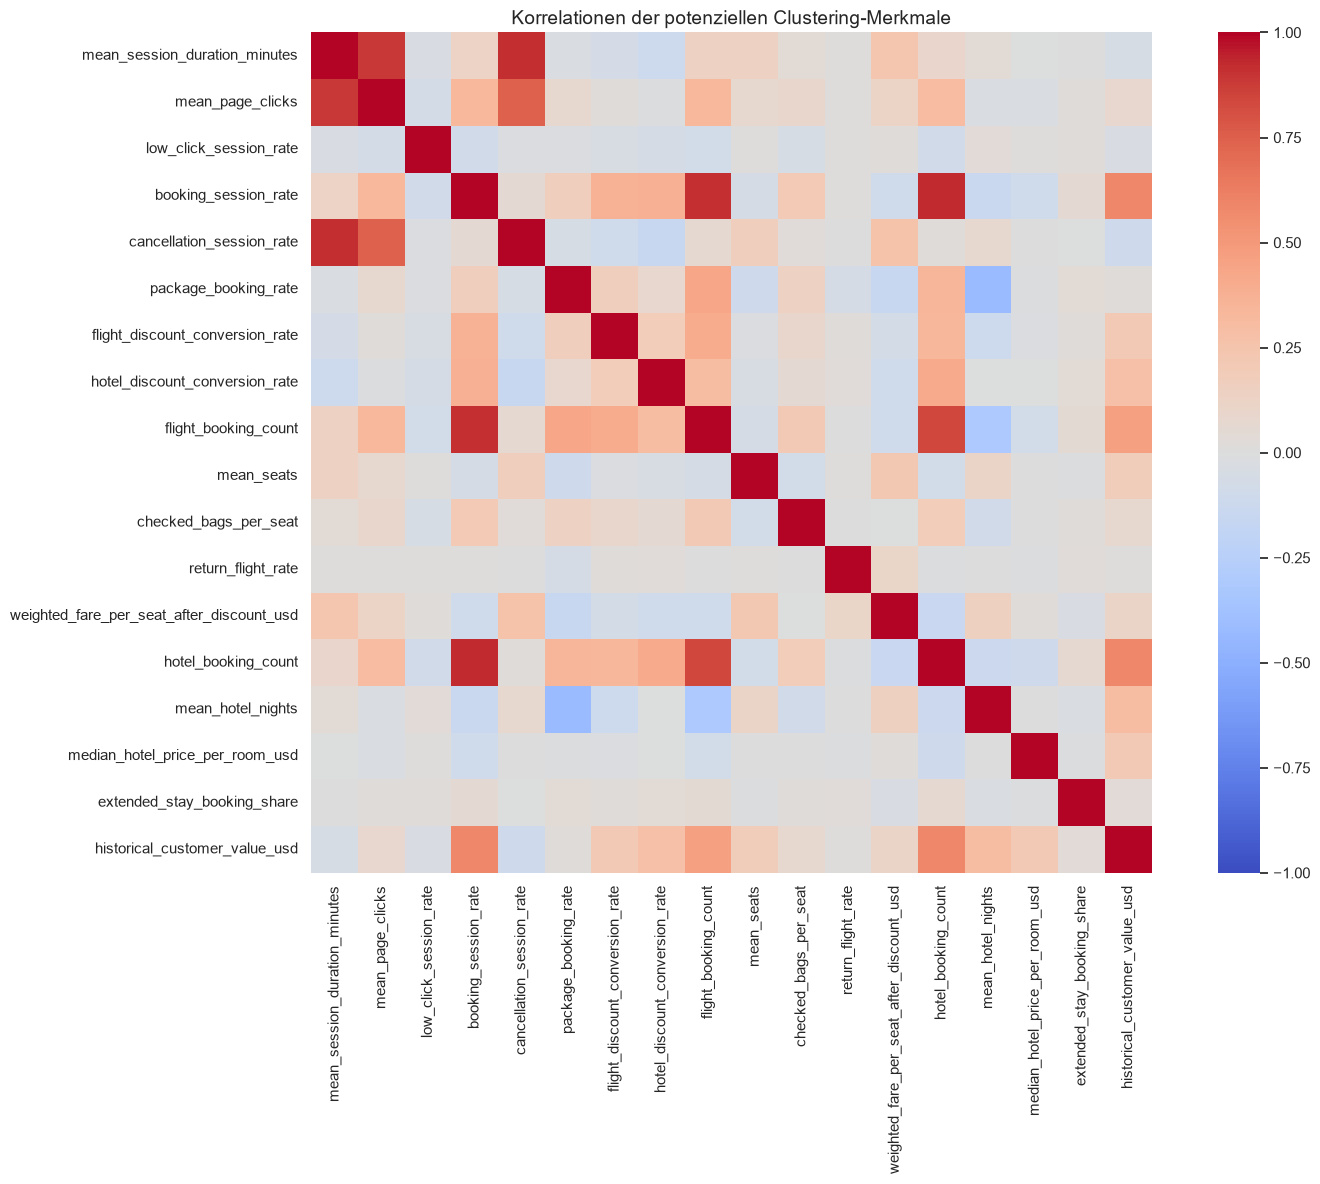

In [12]:
# Korrelationsmatrix der vorausgewählten Merkmale

correlation_matrix = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .corr()
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Korrelationen der potenziellen Clustering-Merkmale",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
# Stark korrelierte Merkmalspaare identifizieren

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

strong_correlations["absolute_correlation"] = (
    strong_correlations["correlation"].abs()
)

strong_correlations = (
    strong_correlations[
        strong_correlations["absolute_correlation"] >= 0.70
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(strong_correlations)

,feature_1,feature_2,correlation,absolute_correlation
67,booking_session_rate,hotel_booking_count,0.927,0.927
4,mean_session_duration_minutes,cancellation_session_rate,0.915,0.915
62,booking_session_rate,flight_booking_count,0.909,0.909
1,mean_session_duration_minutes,mean_page_clicks,0.885,0.885
157,flight_booking_count,hotel_booking_count,0.836,0.836
22,mean_page_clicks,cancellation_session_rate,0.746,0.746
